In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h3
import folium
from branca.colormap import linear

In [4]:
data_orders = pd.read_csv(r'C:\Users\lenovo-miguel\OneDrive\Data_Analysis_projects\Insights_from_Failed_Orders\datasets\data_orders.csv')
data_orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [4]:
data_orders.dtypes

order_datetime                    object
origin_longitude                 float64
origin_latitude                  float64
m_order_eta                      float64
order_gk                           int64
order_status_key                   int64
is_driver_assigned_key             int64
cancellations_time_in_seconds    float64
dtype: object

In [3]:
#change order_datetime type
data_orders["order_datetime"] = pd.to_datetime(
    data_orders["order_datetime"],
    format="%H:%M:%S"
).dt.time
data_orders.head()

,order_datetime,origin_longitude,origin_latitude,m_order_eta,order_gk,order_status_key,is_driver_assigned_key,cancellations_time_in_seconds
0,18:08:07,-0.978916,51.456173,60.0,3000583041974,4,1,198.0
1,20:57:32,-0.950385,51.456843,NaN,3000583116437,4,0,128.0
2,12:07:50,-0.969520,51.455544,477.0,3000582891479,4,1,46.0
3,13:50:20,-1.054671,51.460544,658.0,3000582941169,4,1,62.0
4,21:24:45,-0.967605,51.458236,NaN,3000583140877,9,0,NaN


In [9]:
data_orders.dtypes

order_datetime                    object
origin_longitude                 float64
origin_latitude                  float64
m_order_eta                      float64
order_gk                           int64
order_status_key                   int64
is_driver_assigned_key             int64
cancellations_time_in_seconds    float64
dtype: object

In [10]:
type(data_orders["order_datetime"].iloc[0])

datetime.time

1. Build up distribution of orders according to reasons for failure: cancellations before and after driver assignment, and reasons for order rejection. Analyse the resulting plot. Which category has the highest number of orders?

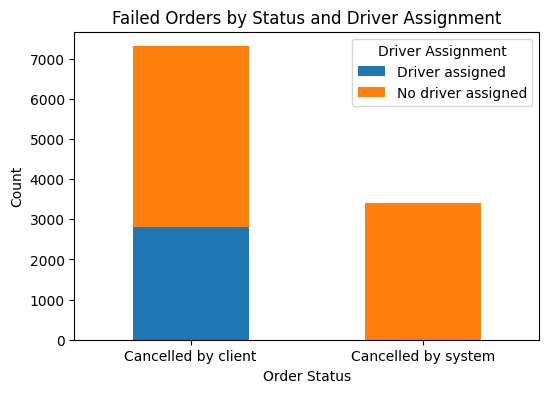

In [15]:
#let's plot the distribution of orders by type of cancellation and driver assignment

plot_data = data_orders.copy()

plot_data["order_status"] = plot_data["order_status_key"].map({
    4: "Cancelled by client",
    9: "Cancelled by system"
})

plot_data["driver_assigned"] = plot_data["is_driver_assigned_key"].map({
    0: "No driver assigned",
    1: "Driver assigned"
})

stacked_counts = pd.crosstab(
    plot_data["order_status"],
    plot_data["driver_assigned"]
)

stacked_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(6, 4)
)

plt.xlabel("Order Status")
plt.ylabel("Count")
plt.title("Failed Orders by Status and Driver Assignment")
plt.legend(title="Driver Assignment")
plt.xticks(rotation=0)
plt.show()

###We can see that the majority of orders was cancelled by the client or the system before driver assignment

2. Plot the distribution of failed orders by hours. Is there a trend that certain hours have an abnormally high proportion of one category or another? What hours are the biggest fails? How can this be explained?

In [6]:
#add a column with order hour
data_orders["order_hour"] = pd.to_datetime(
    data_orders["order_datetime"].astype(str),
    format="%H:%M:%S"
).dt.hour

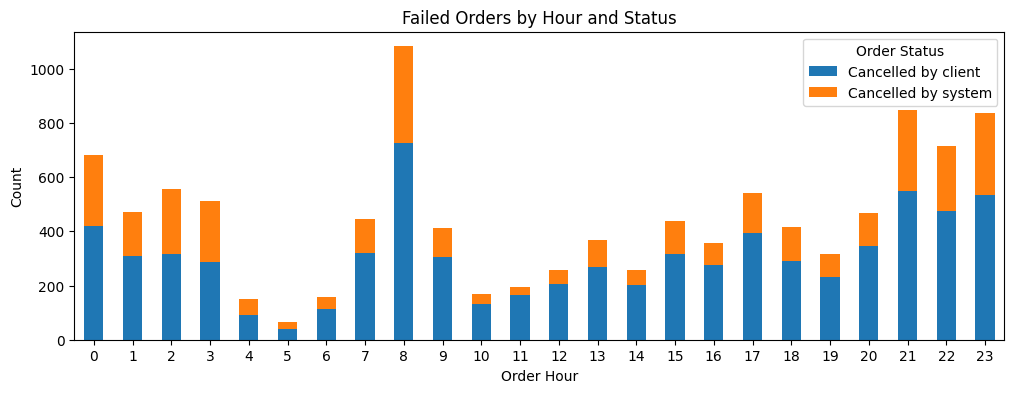

In [8]:
#let's plot the distribution of failed orders by hour and type of cancellation
plot_data = data_orders.copy()

plot_data["order_status"] = plot_data["order_status_key"].map({
    4: "Cancelled by client",
    9: "Cancelled by system"
})

stacked_counts = pd.crosstab(
    plot_data["order_hour"],
    plot_data["order_status"]
)

stacked_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

plt.xlabel("Order Hour")
plt.ylabel("Count")
plt.title("Failed Orders by Hour and Status")
plt.legend(title="Order Status")
plt.xticks(rotation=0)
plt.show()

###The main trend is that **client cancellations dominate almost every hour**, while **system cancellations/rejects are a smaller but steady share** throughout the day.

The biggest fail hours by total failed orders are:

1. **08:00**: clearly the highest failure peak, with more than 1,000 failed orders.
2. **21:00, 23:00, 22:00**: very high evening failure volume.
3. **00:00 to 03:00**: also relatively high, especially for late-night demand.

The most abnormal hour is **08:00**, because both categories rise sharply, especially **cancelled by client**. This suggests a strong morning demand spike, likely commute/work-start behavior. If supply is tight, ETAs increase, drivers may be harder to match, and customers may cancel more often.

The evening hours, especially **21:00 to 23:00**, also look like major failure periods. This may reflect dinner/leisure demand, fewer available drivers, traffic, restaurant/merchant delays, or longer waiting times. Since client cancellations remain the larger category, users may be abandoning orders after waiting too long.

System cancellations/rejects do not appear to dominate any specific hour dramatically, but they increase in the same high-volume windows. That suggests rejects are probably related to demand pressure too: when order volume rises, the platform may fail more often to find/assign a driver within acceptable conditions.

So the short answer: **the biggest operational pain points are 08:00 and 21:00-23:00**. The likely explanation is **demand peaks causing worse matching, longer ETAs, and more customer impatience or system rejection**.

3. Plot the average time to cancellation with and without driver, by the hour. If there are any outliers in the data, it would be better to remove them. Can we draw any conclusions from this plot?

In [9]:
#let's first look for outliers in cancelation time
col = "cancellations_time_in_seconds"
data_orders[col].describe()

count    7307.000000
mean      157.892021
std       213.366963
min         3.000000
25%        45.000000
50%        98.000000
75%       187.500000
max      4303.000000
Name: cancellations_time_in_seconds, dtype: float64

In [15]:
Q1 = data_orders[col].quantile(0.25)
Q3 = data_orders[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data_orders[
    (data_orders[col] < lower_bound) |
    (data_orders[col] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", len(outliers))
print("Percentage of outliers:", round(len(outliers) / len(data_orders) * 100, 2), "%")

Q1: 45.0
Q3: 187.5
IQR: 142.5
Lower bound: -168.75
Upper bound: 401.25
Number of outliers: 592
Percentage of outliers: 5.52 %


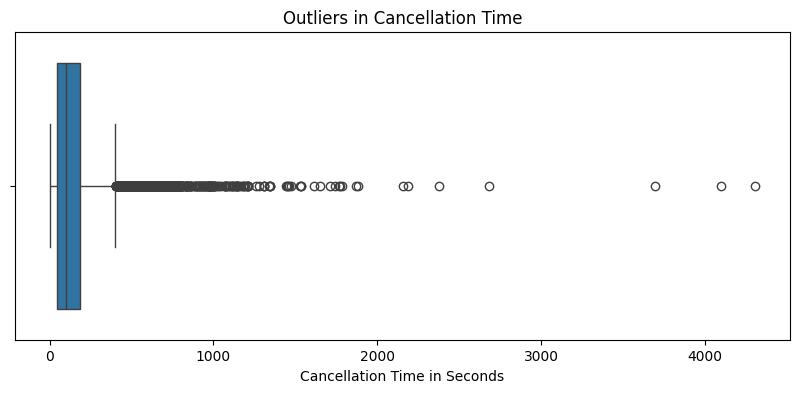

In [16]:
#let's see the boxplot for this cancellation time
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=data_orders,
    x=col
)

plt.title("Outliers in Cancellation Time")
plt.xlabel("Cancellation Time in Seconds")
plt.show()

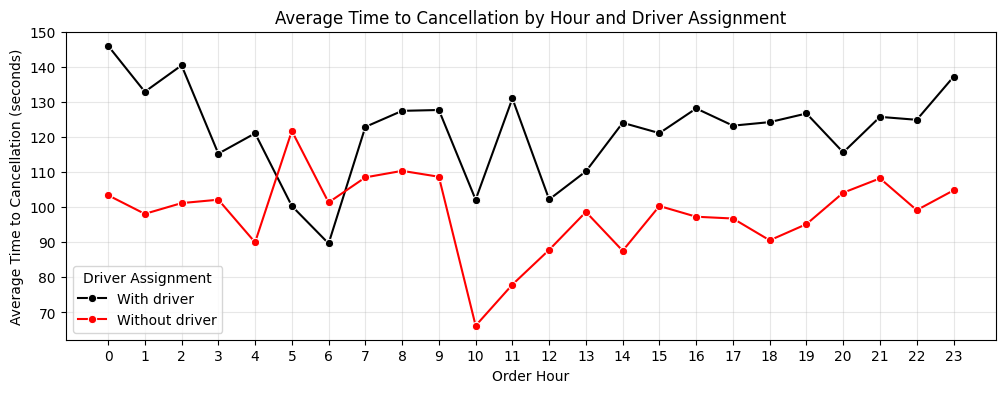

In [19]:
#let's plot the graph
plot_data = data_orders.copy()

col = "cancellations_time_in_seconds"

# Remove rows with missing cancellation time
plot_data = plot_data.dropna(subset=[col])

# Remove outliers using IQR
Q1 = plot_data[col].quantile(0.25)
Q3 = plot_data[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_data = plot_data[
    (plot_data[col] >= lower_bound) &
    (plot_data[col] <= upper_bound)
]

# Make labels easier to read
plot_data["driver_assigned"] = plot_data["is_driver_assigned_key"].map({
    0: "Without driver",
    1: "With driver"
})

# Average cancellation time by hour and driver assignment
avg_cancel_time = (
    plot_data
    .groupby(["order_hour", "driver_assigned"], as_index=False)[col]
    .mean()
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=avg_cancel_time,
    x="order_hour",
    y=col,
    hue="driver_assigned",
    marker="o",
    palette={
        "With driver": "black",
        "Without driver": "red"
            }
)

plt.xlabel("Order Hour")
plt.ylabel("Average Time to Cancellation (seconds)")
plt.title("Average Time to Cancellation by Hour and Driver Assignment")
plt.xticks(range(0, 24))
plt.legend(title="Driver Assignment")
plt.grid(True, alpha=0.3)
plt.show()

###This plot can support a few useful operational conclusions:

The strongest pattern is that **orders with a driver assigned generally take longer to be cancelled** than orders without a driver. The black line is above the red line for most hours. This suggests that once a driver is assigned, customers are more willing to wait, probably because they see progress in the order.

For **orders without a driver**, cancellation usually happens faster, often around **90-110 seconds**. The biggest exception is around **05:00**, where the “without driver” average jumps above the “with driver” line. That could be noise from a small number of observations, so it would be worth checking counts for that hour.

The biggest “fast cancellation” point is around **10:00 without driver**, where average cancellation time drops to about **65 seconds**. That may indicate customers are especially impatient at that hour when no driver is assigned, or that the platform is quickly rejecting/cancelling difficult orders.

For **orders with a driver**, the longest cancellation times appear around **00:00, 02:00, and 23:00**, with averages close to or above **140 seconds**. Late-night users may be more tolerant after a driver is assigned, possibly because fewer alternatives are available or they expect longer waits.

Overall: **driver assignment seems to increase customer patience**, while lack of assignment leads to quicker cancellations. The most suspicious hours to investigate further are **05:00 and 10:00**, because they stand out from the surrounding pattern.

In [21]:
plot_data.groupby(["order_hour", "driver_assigned"]).size().reset_index(name="count")

,order_hour,driver_assigned,count
0,0,With driver,91
1,0,Without driver,293
2,1,With driver,71
3,1,Without driver,219
4,2,With driver,55
5,2,Without driver,234
6,3,With driver,46
7,3,Without driver,223
8,4,With driver,32
9,4,Without driver,50


###We see that there are few observations for hour 5:00, so this sudden increase in time to cancel is not a reliable information!

4. Plot the distribution of average ETA by hours. How can this plot be explained?

In [24]:
col = 'm_order_eta'
data_orders[col].describe()

count    2814.000000
mean      441.415423
std       288.006379
min        60.000000
25%       233.000000
50%       368.500000
75%       653.000000
max      1559.000000
Name: m_order_eta, dtype: float64

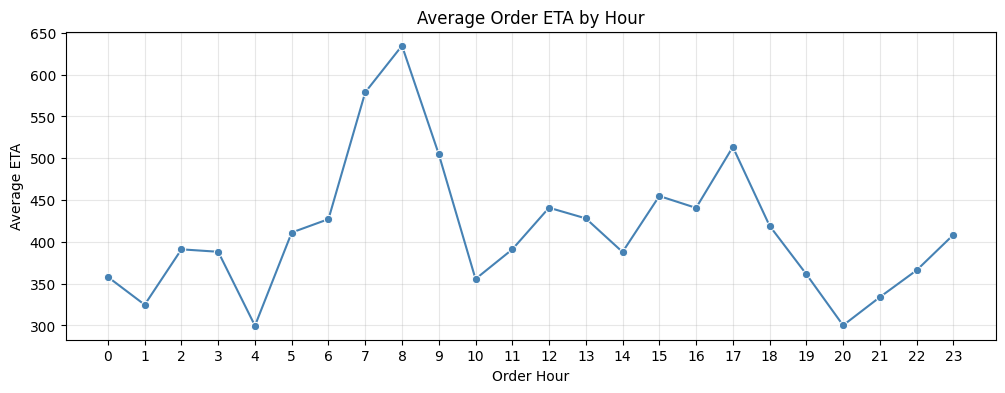

In [26]:
plot_data = data_orders.copy()

col = "m_order_eta"

# Remove rows with missing ETA
plot_data = plot_data.dropna(subset=[col])

# Remove outliers using IQR
Q1 = plot_data[col].quantile(0.25)
Q3 = plot_data[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_data = plot_data[
    (plot_data[col] >= lower_bound) &
    (plot_data[col] <= upper_bound)
]

# Average ETA by hour
avg_eta_by_hour = (
    plot_data
    .groupby("order_hour", as_index=False)[col]
    .mean()
)

plt.figure(figsize=(12, 4))

sns.lineplot(
    data=avg_eta_by_hour,
    x="order_hour",
    y=col,
    marker="o",
    color="steelblue"
)

plt.xlabel("Order Hour")
plt.ylabel("Average ETA")
plt.title("Average Order ETA by Hour")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

###This plot suggests that ETA is strongly affected by **time-of-day demand and driver availability**.

The clearest pattern is the sharp morning peak around **07:00-09:00**, especially **08:00**, where average ETA reaches its highest point. This fits very well with the earlier failed-orders plot, where **08:00 was also the biggest failure hour**. A likely explanation is a morning rush: many users are placing orders at the same time, but driver supply may not scale fast enough, so the platform estimates longer pickup/arrival times.

There is also a second elevated period around **15:00-17:00**, with a noticeable peak at **17:00**. This may reflect afternoon/evening transition demand, traffic congestion, or reduced driver availability before the dinner period.

The lowest ETA points appear around **04:00** and **20:00**, close to 300 seconds. These may be periods where either demand is lower or orders are easier to match. That said, very early hours like **04:00** may have fewer observations, so it would be good to check sample size before trusting that dip too strongly.

The interesting comparison is with cancellation behavior: high ETA around **08:00** likely helps explain why failures spike at that hour. Longer ETAs can make customers cancel before assignment, or make the system reject orders if matching conditions are poor.

So the main explanation is: **ETA increases when demand pressure and/or traffic is high, especially during the morning rush, and those high ETA periods likely contribute to failed orders.**

In [27]:
plot_data.groupby(["order_hour"]).size().reset_index(name="count")

,order_hour,count
0,0,122
1,1,88
2,2,78
3,3,64
4,4,41
5,5,25
6,6,47
7,7,155
8,8,313
9,9,156


5. Hexagons. Using the h3 and folium packages, calculate how many sizes 8 hexes contain 80% of all orders from the original data sets and visualise the hexes, colouring them by the number of fails on the map.

In [29]:
#find hexes that cointain 80% of all orders
# Use only rows with valid coordinates
geo_data = data_orders.dropna(subset=["origin_latitude", "origin_longitude"]).copy()

# H3 resolution
h3_resolution = 8

# Convert each order origin into an H3 hexagon
geo_data["h3_hex"] = geo_data.apply(
    lambda row: h3.latlng_to_cell(
        row["origin_latitude"],
        row["origin_longitude"],
        h3_resolution
    ),
    axis=1
)

# Count failed orders per hex
hex_counts = (
    geo_data
    .groupby("h3_hex")
    .size()
    .reset_index(name="fail_count")
    .sort_values("fail_count", ascending=False)
)

# Calculate cumulative share of failed orders
total_orders = hex_counts["fail_count"].sum()

hex_counts["cumulative_fails"] = hex_counts["fail_count"].cumsum()
hex_counts["cumulative_share"] = hex_counts["cumulative_fails"] / total_orders

# Select the size 8 hexes that contain 80% of all failed orders
hexes_80 = hex_counts[hex_counts["cumulative_share"] <= 0.80].copy()

# Include the first hex that pushes cumulative share over 80%, if needed
if len(hexes_80) < len(hex_counts):
    first_over_80 = hex_counts.iloc[[len(hexes_80)]]
    hexes_80 = pd.concat([hexes_80, first_over_80])

print(f"Number of resolution {h3_resolution} hexes containing 80% of orders: {len(hexes_80)}")
print(f"Total failed orders in selected hexes: {hexes_80['fail_count'].sum()}")
print(f"Share of failed orders covered: {hexes_80['fail_count'].sum() / total_orders:.2%}")

Number of resolution 8 hexes containing 80% of orders: 24
Total failed orders in selected hexes: 8634
Share of failed orders covered: 80.57%


In [31]:
#plot chart
# Center map around the average order location
map_center = [
    geo_data["origin_latitude"].mean(),
    geo_data["origin_longitude"].mean()
]

m = folium.Map(
    location=map_center,
    zoom_start=11,
    tiles="cartodbpositron"
)

# Color scale based on fail counts
colormap = linear.YlOrRd_09.scale(
    hexes_80["fail_count"].min(),
    hexes_80["fail_count"].max()
)

colormap.caption = "Number of failed orders"
colormap.add_to(m)

# Draw each H3 hexagon
for _, row in hexes_80.iterrows():
    hex_id = row["h3_hex"]
    fail_count = row["fail_count"]

    # Get boundary coordinates for the hexagon
    boundary = h3.cell_to_boundary(hex_id)

    # Folium expects coordinates as [lat, lon]
    boundary = [[lat, lng] for lat, lng in boundary]

    folium.Polygon(
        locations=boundary,
        color="black",
        weight=0.5,
        fill=True,
        fill_color=colormap(fail_count),
        fill_opacity=0.7,
        popup=f"Hex: {hex_id}<br>Failed orders: {fail_count}"
    ).add_to(m)
m